In [ ]:
from google.colab import files
uploaded=files.upload()
print(uploaded)


Saving proj1.csv to proj1.csv
{'proj1.csv': b'06.15 6:34 AM\nStudent_ID,Name,Age,Gender,Department,Study_Hours_Per_Day,Attendance_Percentage,Assignments_Completed,Midterm_Score,Final_Score,Projects_Score,Extra_Curricular,Internet_Access,Family_Income,Parent_Education,Sleep_Hours,Stress_Level,Final_Grade\nS001,Alice Johnson,20,Female,Computer Science,6,92,18,78,82,88,Yes,Yes,High,Graduate,7,Low,A\nS002,Bob Smith,21,Male,Mathematics,4,85,15,65,70,72,No,Yes,Medium,Undergraduate,6,Medium,B\nS003,Carol White,19,Female,Physics,7,95,20,88,91,90,Yes,Yes,High,Graduate,8,Low,A\nS004,David Brown,22,Male,Chemistry,3,70,12,55,58,60,No,No,Low,High School,5,High,C\nS005,Emma Davis,20,Female,Computer Science,5,88,17,75,79,80,Yes,Yes,Medium,Graduate,7,Low,B\nS006,Frank Miller,23,Male,Mathematics,2,65,10,45,50,48,No,No,Low,High School,4,High,D\nS007,Grace Wilson,21,Female,Physics,6,90,19,82,85,87,Yes,Yes,High,Graduate,7,Low,A\nS008,Henry Moore,20,Male,Chemistry,4,80,14,68,72,70,No,Yes,Medium,Undergradua

In [ ]:
# ============================================================
# PROJECT 3 – DATA VISUALIZATION WITH PYTHON
# ============================================================

# Install required libraries
# pip install matplotlib seaborn pandas numpy plotly

# Import all necessary libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# ============================================================
# GLOBAL STYLE SETTINGS
# Consistent colors, fonts, and layouts across all charts
# ============================================================

# Set a clean, professional style
plt.style.use('seaborn-v0_8-whitegrid')

# Define a consistent color palette
COLOR_PALETTE = ['#2196F3', '#4CAF50', '#FF9800', '#F44336',
                 '#9C27B0', '#00BCD4', '#FF5722', '#607D8B']

# Define consistent font settings
TITLE_FONT   = {'fontsize': 16, 'fontweight': 'bold', 'color': '#2C3E50'}
LABEL_FONT   = {'fontsize': 12, 'color': '#555555'}
TICK_FONT    = {'labelsize': 10}

# Set default figure size
DEFAULT_SIZE = (10, 6)

print("✅ Libraries loaded and global styles set successfully!")
print(f"   Color Palette : {COLOR_PALETTE[:4]} ...")
print(f"   Default Size  : {DEFAULT_SIZE}")

✅ Libraries loaded and global styles set successfully!
   Color Palette : ['#2196F3', '#4CAF50', '#FF9800', '#F44336'] ...
   Default Size  : (10, 6)


In [ ]:
# ============================================================
# DATASET CREATION
# Simulated sales data for a retail company (2023)
# ============================================================

# Seed for reproducibility
np.random.seed(42)

# --- Monthly Sales Data ---
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

sales_data = pd.DataFrame({
    'Month'       : months,
    'Electronics' : [45000, 48000, 52000, 49000, 61000, 58000,
                     63000, 71000, 68000, 74000, 89000, 95000],
    'Clothing'    : [32000, 29000, 35000, 41000, 38000, 43000,
                     47000, 44000, 52000, 56000, 71000, 78000],
    'Food'        : [28000, 27000, 30000, 31000, 33000, 35000,
                     36000, 35000, 38000, 40000, 45000, 50000],
    'Furniture'   : [15000, 18000, 22000, 25000, 21000, 19000,
                     17000, 20000, 24000, 22000, 28000, 35000]
})

# --- Customer Satisfaction Data ---
satisfaction_data = pd.DataFrame({
    'Category'  : ['Electronics', 'Clothing', 'Food', 'Furniture'],
    'Satisfied' : [65, 72, 80, 58],
    'Neutral'   : [20, 18, 12, 25],
    'Unhappy'   : [15, 10,  8, 17]
})

# --- Customer Age & Spending Data (for scatter plot) ---
customer_data = pd.DataFrame({
    'Age'         : np.random.randint(18, 70, 200),
    'Spending'    : np.random.normal(500, 150, 200).clip(100, 1000),
    'Visits'      : np.random.randint(1, 20, 200),
    'Category'    : np.random.choice(['Electronics', 'Clothing',
                                       'Food', 'Furniture'], 200)
})

# --- Store Performance Data (for heatmap) ---
store_performance = pd.DataFrame(
    np.random.randint(60, 100, size=(4, 12)),
    columns=months,
    index=['Store A', 'Store B', 'Store C', 'Store D']
)

# Display a summary
print("=" * 55)
print("         DATASET SUMMARY")
print("=" * 55)
print(f"\n📊 Sales Data       : {sales_data.shape[0]} rows × "
      f"{sales_data.shape[1]} columns")
print(f"📊 Satisfaction Data: {satisfaction_data.shape[0]} rows × "
      f"{satisfaction_data.shape[1]} columns")
print(f"📊 Customer Data    : {customer_data.shape[0]} rows × "
      f"{customer_data.shape[1]} columns")
print(f"📊 Store Performance: {store_performance.shape[0]} rows × "
      f"{store_performance.shape[1]} columns")

print("\n--- Sales Data Preview ---")
print(sales_data.head(3).to_string(index=False))

print("\n--- Customer Data Preview ---")
print(customer_data.head(3).to_string(index=False))

         DATASET SUMMARY

📊 Sales Data       : 12 rows × 5 columns
📊 Satisfaction Data: 4 rows × 4 columns
📊 Customer Data    : 200 rows × 4 columns
📊 Store Performance: 4 rows × 12 columns

--- Sales Data Preview ---
Month  Electronics  Clothing  Food  Furniture
  Jan        45000     32000 28000      15000
  Feb        48000     29000 27000      18000
  Mar        52000     35000 30000      22000

--- Customer Data Preview ---
 Age   Spending  Visits  Category
  56 519.051836      11 Furniture
  69 312.583442       4      Food
  46 791.767342       4      Food


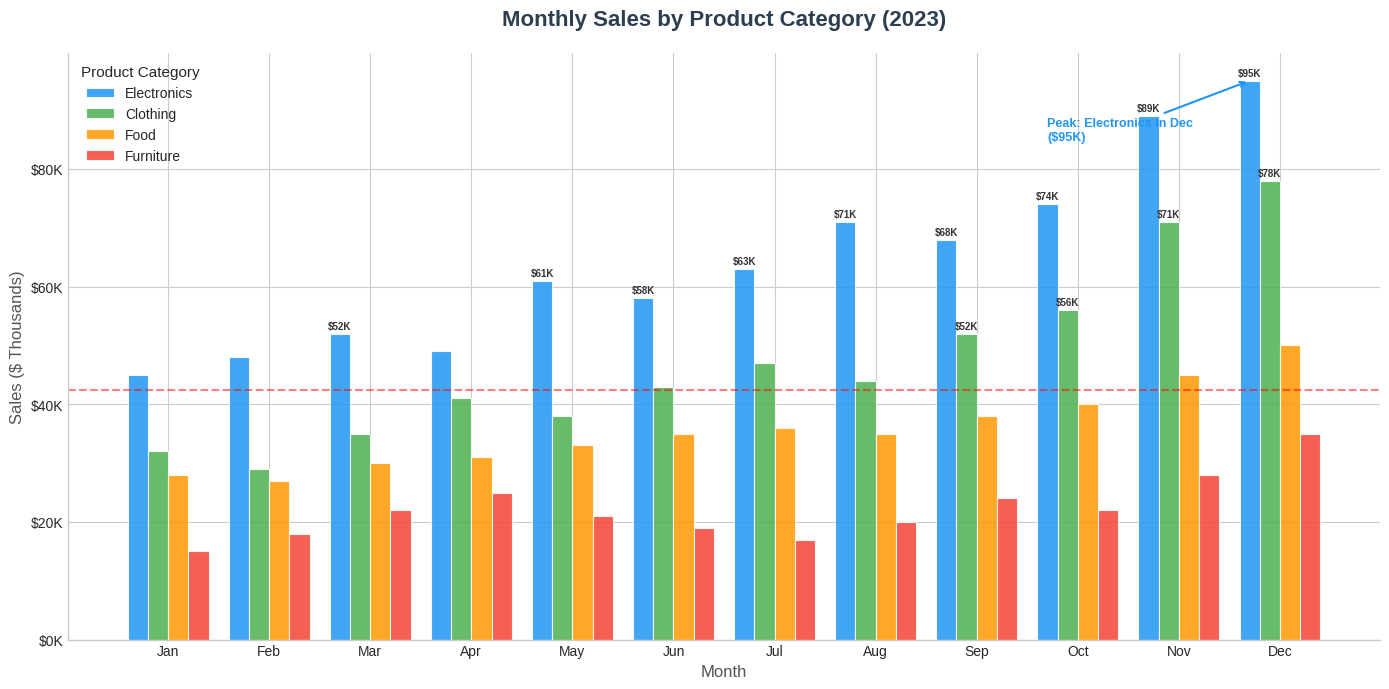

✅ Bar Chart saved as 'chart1_bar_chart.png'


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# ============================================================
# GLOBAL STYLE SETTINGS
# Consistent colors, fonts, and layouts across all charts
# ============================================================

# Set a clean, professional style
plt.style.use('seaborn-v0_8-whitegrid')

# Define a consistent color palette
COLOR_PALETTE = ['#2196F3', '#4CAF50', '#FF9800', '#F44336',
                 '#9C27B0', '#00BCD4', '#FF5722', '#607D8B']

# Define consistent font settings
TITLE_FONT   = {'fontsize': 16, 'fontweight': 'bold', 'color': '#2C3E50'}
LABEL_FONT   = {'fontsize': 12, 'color': '#555555'}
TICK_FONT    = {'labelsize': 10}

# Set default figure size
DEFAULT_SIZE = (10, 6)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# ============================================================
# CHART 1 – BAR CHART
# Purpose : Compare sales across categories each month
# Message : Which category generates the most revenue?
# ============================================================
sales_data = pd.DataFrame({
    'Month'       : months,
    'Electronics' : [45000, 48000, 52000, 49000, 61000, 58000,
                     63000, 71000, 68000, 74000, 89000, 95000],
    'Clothing'    : [32000, 29000, 35000, 41000, 38000, 43000,
                     47000, 44000, 52000, 56000, 71000, 78000],
    'Food'        : [28000, 27000, 30000, 31000, 33000, 35000,
                     36000, 35000, 38000, 40000, 45000, 50000],
    'Furniture'   : [15000, 18000, 22000, 25000, 21000, 19000,
                     17000, 20000, 24000, 22000, 28000, 35000]
})
def plot_bar_chart(sales_data):
    """
    Grouped bar chart showing monthly sales per category.
    Best for: Comparing values across multiple groups.
    """
    fig, ax = plt.subplots(figsize=(14, 7))

    # --- Data Preparation ---
    categories = ['Electronics', 'Clothing', 'Food', 'Furniture']
    x          = np.arange(len(sales_data['Month']))  # x positions
    bar_width  = 0.2                             # width of each bar

    # --- Plot Each Category ---
    for i, (category, color) in enumerate(zip(categories, COLOR_PALETTE)):
        bars = ax.bar(
            x + i * bar_width,          # offset each group
            sales_data[category] / 1000,      # convert to thousands
            width     = bar_width,
            label     = category,
            color     = color,
            alpha     = 0.85,
            edgecolor = 'white',
            linewidth = 0.8
        )

        # Add value labels on top of each bar
        for bar in bars:
            height = bar.get_height()
            if height > 50:             # only label bars above $50K
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + 0.5,
                    f'${height:.0f}K',
                    ha        = 'center',
                    va        = 'bottom',
                    fontsize  = 7,
                    color     = '#333333',
                    fontweight= 'bold'
                )

    # --- Styling ---
    ax.set_title('Monthly Sales by Product Category (2023)',
                 **TITLE_FONT, pad=20)
    ax.set_xlabel('Month', **LABEL_FONT)
    ax.set_ylabel('Sales ($ Thousands)', **LABEL_FONT)

    # Set x-axis tick positions to center of grouped bars
    ax.set_xticks(x + bar_width * 1.5)
    ax.set_xticklabels(sales_data['Month'])
    ax.tick_params(axis='both', **TICK_FONT)

    # Format y-axis with dollar sign
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda val, _: f'${val:.0f}K')
    )

    # Add legend outside the plot
    ax.legend(
        title      = 'Product Category',
        loc        = 'upper left',
        fontsize   = 10,
        title_fontsize = 11,
        framealpha = 0.9
    )

    # Add a horizontal line for average total sales
    avg_total = sales_data[categories].mean().mean() / 1000
    ax.axhline(
        y         = avg_total,
        color     = 'red',
        linestyle = '--',
        alpha     = 0.5,
        linewidth = 1.5,
        label     = f'Overall Avg: ${avg_total:.1f}K'
    )

    # Add annotation
    ax.annotate(
        f'Peak: Electronics in Dec\n($95K)',
        xy         = (11 + 0 * bar_width, 95),
        xytext     = (9, 85),
        fontsize   = 9,
        color      = '#2196F3',
        fontweight = 'bold',
        arrowprops = dict(arrowstyle='->', color='#2196F3', lw=1.5)
    )

    # Clean layout
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('chart1_bar_chart.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Bar Chart saved as 'chart1_bar_chart.png'")


# Run the function
plot_bar_chart(sales_data)

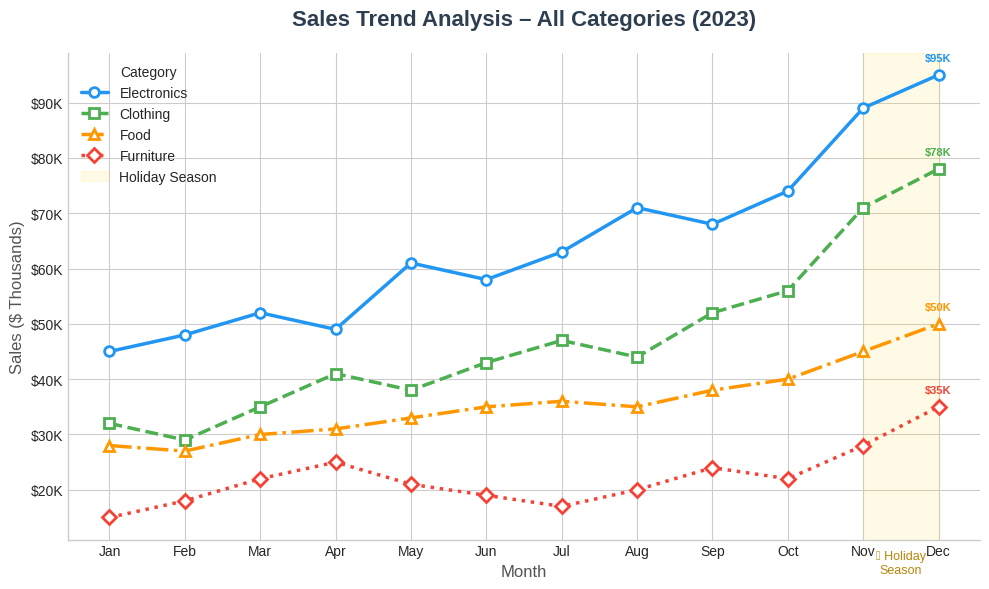

✅ Line Chart saved as 'chart2_line_chart.png'


In [ ]:
# ============================================================
# CHART 2 – LINE CHART
# Purpose : Show sales trends across the year
# Message : How does each category grow month over month?
# ============================================================

def plot_line_chart(data):
    """
    Multi-line chart showing sales trends over 12 months.
    Best for: Showing trends and changes over time.
    """
    fig, ax = plt.subplots(figsize=DEFAULT_SIZE)

    categories  = ['Electronics', 'Clothing', 'Food', 'Furniture']
    line_styles = ['-', '--', '-.', ':']
    markers     = ['o', 's', '^', 'D']

    # --- Plot Each Category ---
    for category, color, ls, marker in zip(
            categories, COLOR_PALETTE, line_styles, markers):

        values = data[category] / 1000

        ax.plot(
            data['Month'],
            values,
            label     = category,
            color     = color,
            linestyle = ls,
            marker    = marker,
            markersize= 7,
            linewidth = 2.5,
            markerfacecolor = 'white',
            markeredgewidth = 2
        )

        # Highlight the maximum point for each category
        max_idx = values.idxmax()
        ax.annotate(
            f'${values[max_idx]:.0f}K',
            xy        = (data['Month'][max_idx], values[max_idx]),
            xytext    = (0, 10),
            textcoords= 'offset points',
            ha        = 'center',
            fontsize  = 8,
            color     = color,
            fontweight= 'bold'
        )

    # --- Shade the Holiday Season (Nov-Dec) ---
    ax.axvspan(10, 11, alpha=0.1, color='gold', label='Holiday Season')
    ax.text(10.5, 5, '🎄 Holiday\nSeason',
            ha='center', fontsize=9, color='#B8860B')

    # --- Styling ---
    ax.set_title('Sales Trend Analysis – All Categories (2023)',
                 **TITLE_FONT, pad=20)
    ax.set_xlabel('Month', **LABEL_FONT)
    ax.set_ylabel('Sales ($ Thousands)', **LABEL_FONT)
    ax.tick_params(**TICK_FONT)

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda val, _: f'${val:.0f}K')
    )

    ax.legend(
        title      = 'Category',
        loc        = 'upper left',
        fontsize   = 10,
        framealpha = 0.9
    )

    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('chart2_line_chart.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Line Chart saved as 'chart2_line_chart.png'")


plot_line_chart(sales_data)

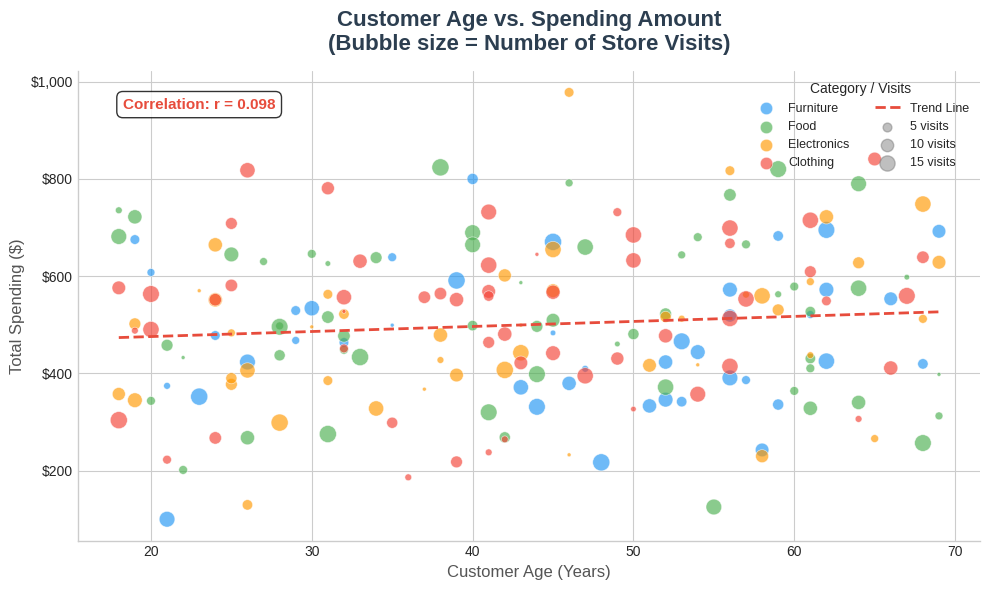

✅ Scatter Plot saved as 'chart3_scatter_plot.png'


In [ ]:
# ============================================================
# CHART 3 – SCATTER PLOT
# Purpose : Explore relationship between age and spending
# Message : Do older customers spend more?
# ============================================================

def plot_scatter_chart(data):
    """
    Scatter plot with regression line, colored by category.
    Best for: Showing relationships between two numeric variables.
    """
    fig, ax = plt.subplots(figsize=DEFAULT_SIZE)

    categories = data['Category'].unique()

    # --- Plot Each Category ---
    for category, color in zip(categories, COLOR_PALETTE):
        subset = data[data['Category'] == category]
        ax.scatter(
            subset['Age'],
            subset['Spending'],
            label     = category,
            color     = color,
            alpha     = 0.65,
            s         = subset['Visits'] * 8,   # size = number of visits
            edgecolors= 'white',
            linewidths= 0.5
        )

    # --- Add Overall Regression Line ---
    z    = np.polyfit(data['Age'], data['Spending'], 1)
    p    = np.poly1d(z)
    x_line = np.linspace(data['Age'].min(), data['Age'].max(), 100)

    ax.plot(
        x_line,
        p(x_line),
        color     = '#E74C3C',
        linewidth = 2,
        linestyle = '--',
        label     = 'Trend Line',
        zorder    = 5
    )

    # Calculate and display correlation
    correlation = data['Age'].corr(data['Spending'])
    ax.text(
        0.05, 0.92,
        f'Correlation: r = {correlation:.3f}',
        transform  = ax.transAxes,
        fontsize   = 11,
        color      = '#E74C3C',
        fontweight = 'bold',
        bbox       = dict(boxstyle='round,pad=0.4',
                          facecolor='white', alpha=0.8)
    )

    # --- Add bubble size legend ---
    for visits, label in [(5, '5 visits'), (10, '10 visits'), (15, '15 visits')]:
        ax.scatter([], [], s=visits*8, color='gray',
                   alpha=0.5, label=f'{label}')

    # --- Styling ---
    ax.set_title('Customer Age vs. Spending Amount\n'
                 '(Bubble size = Number of Store Visits)',
                 **TITLE_FONT, pad=15)
    ax.set_xlabel('Customer Age (Years)', **LABEL_FONT)
    ax.set_ylabel('Total Spending ($)', **LABEL_FONT)
    ax.tick_params(**TICK_FONT)

    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda val, _: f'${val:,.0f}')
    )

    ax.legend(
        title      = 'Category / Visits',
        loc        = 'upper right',
        fontsize   = 9,
        framealpha = 0.9,
        ncol       = 2
    )

    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('chart3_scatter_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Scatter Plot saved as 'chart3_scatter_plot.png'")


plot_scatter_chart(customer_data)

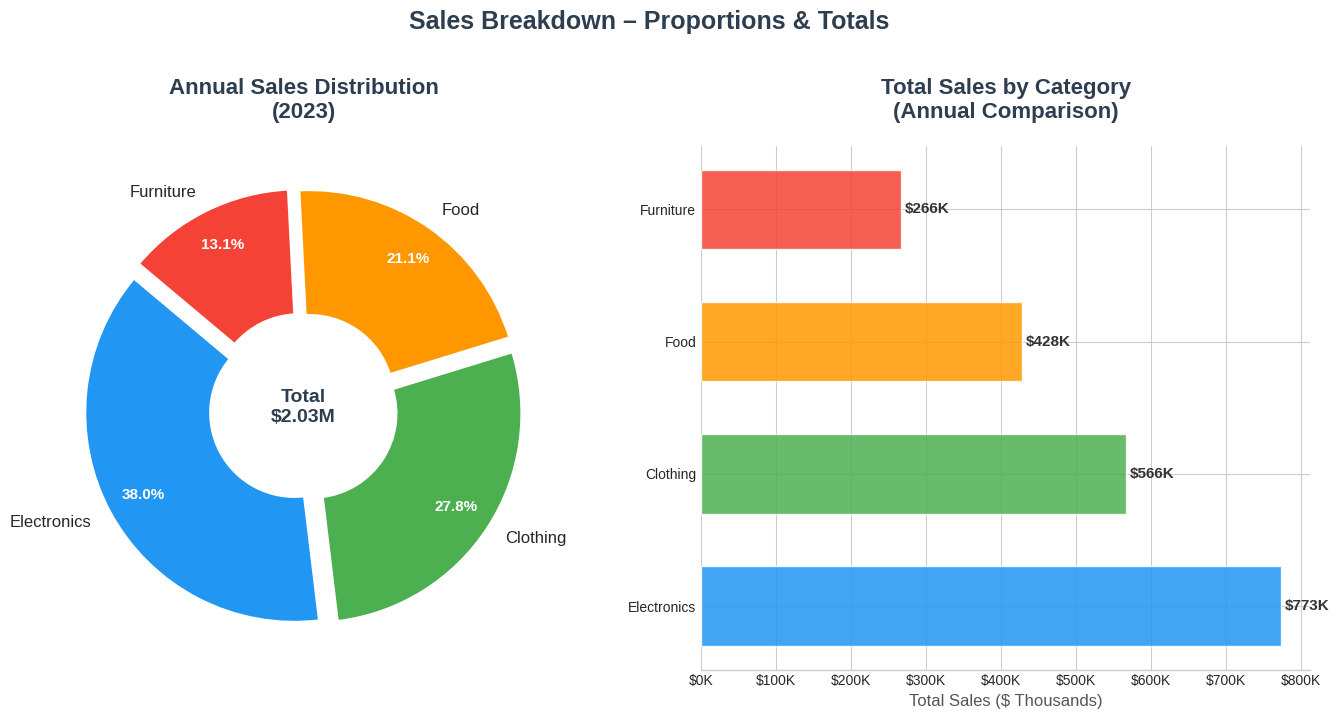

✅ Pie Chart saved as 'chart4_pie_chart.png'


In [ ]:
# ============================================================
# CHART 4 – PIE CHART
# Purpose : Show proportion of total sales per category
# Message : What percentage does each category contribute?
# ============================================================

def plot_pie_chart(data):
    """
    Donut-style pie chart for annual sales distribution.
    Best for: Showing part-to-whole relationships.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    categories  = ['Electronics', 'Clothing', 'Food', 'Furniture']
    total_sales = [data[cat].sum() for cat in categories]
    explode     = [0.05, 0.05, 0.05, 0.05]   # slight separation

    # ---- LEFT: Donut Pie Chart ----
    wedges, texts, autotexts = axes[0].pie(
        total_sales,
        labels     = categories,
        colors     = COLOR_PALETTE[:4],
        autopct    = '%1.1f%%',
        startangle = 140,
        explode    = explode,
        pctdistance= 0.82,
        wedgeprops = dict(width=0.6, edgecolor='white', linewidth=2)
    )

    # Style the percentage labels
    for autotext in autotexts:
        autotext.set_fontsize(11)
        autotext.set_fontweight('bold')
        autotext.set_color('white')

    # Style the category labels
    for text in texts:
        text.set_fontsize(12)

    # Add total in the center of the donut
    total = sum(total_sales)
    axes[0].text(
        0, 0,
        f'Total\n${total/1000000:.2f}M',
        ha         = 'center',
        va         = 'center',
        fontsize   = 14,
        fontweight = 'bold',
        color      = '#2C3E50'
    )

    axes[0].set_title('Annual Sales Distribution\n(2023)',
                      **TITLE_FONT, pad=20)

    # ---- RIGHT: Horizontal Bar for Comparison ----
    sorted_idx  = np.argsort(total_sales)[::-1]
    sorted_cats = [categories[i] for i in sorted_idx]
    sorted_vals = [total_sales[i] / 1000 for i in sorted_idx]
    sorted_cols = [COLOR_PALETTE[i] for i in sorted_idx]

    bars = axes[1].barh(
        sorted_cats,
        sorted_vals,
        color     = sorted_cols,
        edgecolor = 'white',
        height    = 0.6,
        alpha     = 0.85
    )

    # Add value labels
    for bar, val in zip(bars, sorted_vals):
        axes[1].text(
            val + 5,
            bar.get_y() + bar.get_height() / 2,
            f'${val:.0f}K',
            va         = 'center',
            fontsize   = 11,
            fontweight = 'bold',
            color      = '#333333'
        )

    axes[1].set_title('Total Sales by Category\n(Annual Comparison)',
                      **TITLE_FONT, pad=20)
    axes[1].set_xlabel('Total Sales ($ Thousands)', **LABEL_FONT)
    axes[1].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda val, _: f'${val:.0f}K')
    )
    axes[1].spines[['top', 'right', 'left']].set_visible(False)
    axes[1].tick_params(**TICK_FONT)

    plt.suptitle('Sales Breakdown – Proportions & Totals',
                 fontsize=18, fontweight='bold', color='#2C3E50', y=1.02)
    plt.tight_layout()
    plt.savefig('chart4_pie_chart.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Pie Chart saved as 'chart4_pie_chart.png'")


plot_pie_chart(sales_data)

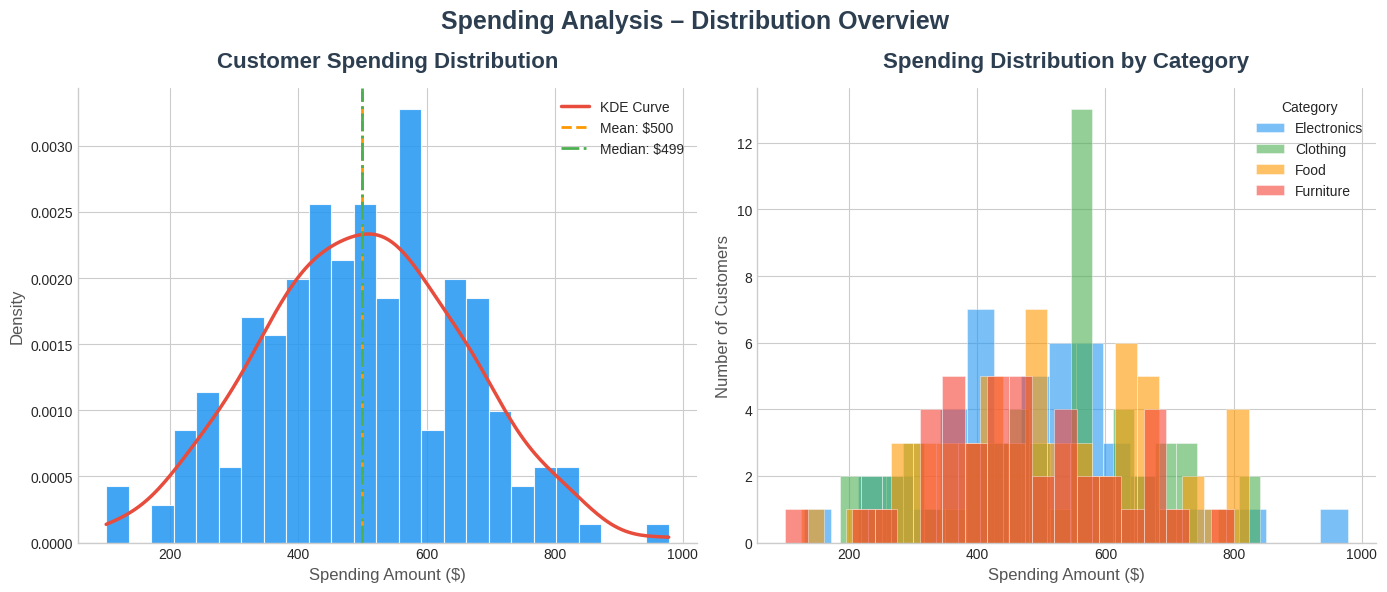

✅ Histogram saved as 'chart5_histogram.png'


In [ ]:
# ============================================================
# CHART 5 – HISTOGRAM
# Purpose : Show distribution of customer spending
# Message : What is the most common spending range?
# ============================================================

def plot_histogram(data):
    """
    Histogram with KDE curve for spending distribution.
    Best for: Understanding distribution of a single variable.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ---- LEFT: Overall Spending Distribution ----
    axes[0].hist(
        data['Spending'],
        bins      = 25,
        color     = COLOR_PALETTE[0],
        edgecolor = 'white',
        linewidth = 0.8,
        alpha     = 0.85,
        density   = True           # normalize to show density
    )

    # Add KDE (Kernel Density Estimate) curve
    from scipy.stats import gaussian_kde
    kde    = gaussian_kde(data['Spending'])
    x_kde  = np.linspace(data['Spending'].min(),
                          data['Spending'].max(), 300)
    axes[0].plot(x_kde, kde(x_kde),
                 color='#E74C3C', linewidth=2.5, label='KDE Curve')

    # Add vertical lines for mean and median
    mean_val   = data['Spending'].mean()
    median_val = data['Spending'].median()

    axes[0].axvline(mean_val,   color='#FF9800', lw=2,
                    linestyle='--', label=f'Mean: ${mean_val:.0f}')
    axes[0].axvline(median_val, color='#4CAF50', lw=2,
                    linestyle='-.',label=f'Median: ${median_val:.0f}')

    axes[0].set_title('Customer Spending Distribution',
                      **TITLE_FONT, pad=15)
    axes[0].set_xlabel('Spending Amount ($)', **LABEL_FONT)
    axes[0].set_ylabel('Density', **LABEL_FONT)
    axes[0].legend(fontsize=10, framealpha=0.9)
    axes[0].spines[['top', 'right']].set_visible(False)
    axes[0].tick_params(**TICK_FONT)

    # ---- RIGHT: Spending by Category (Stacked) ----
    categories = ['Electronics', 'Clothing', 'Food', 'Furniture']

    for category, color in zip(categories, COLOR_PALETTE):
        subset = data[data['Category'] == category]['Spending']
        axes[1].hist(
            subset,
            bins      = 20,
            label     = category,
            color     = color,
            edgecolor = 'white',
            linewidth = 0.5,
            alpha     = 0.6
        )

    axes[1].set_title('Spending Distribution by Category',
                      **TITLE_FONT, pad=15)
    axes[1].set_xlabel('Spending Amount ($)', **LABEL_FONT)
    axes[1].set_ylabel('Number of Customers', **LABEL_FONT)
    axes[1].legend(title='Category', fontsize=10, framealpha=0.9)
    axes[1].spines[['top', 'right']].set_visible(False)
    axes[1].tick_params(**TICK_FONT)

    plt.suptitle('Spending Analysis – Distribution Overview',
                 fontsize=18, fontweight='bold', color='#2C3E50')
    plt.tight_layout()
    plt.savefig('chart5_histogram.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Histogram saved as 'chart5_histogram.png'")


plot_histogram(customer_data)

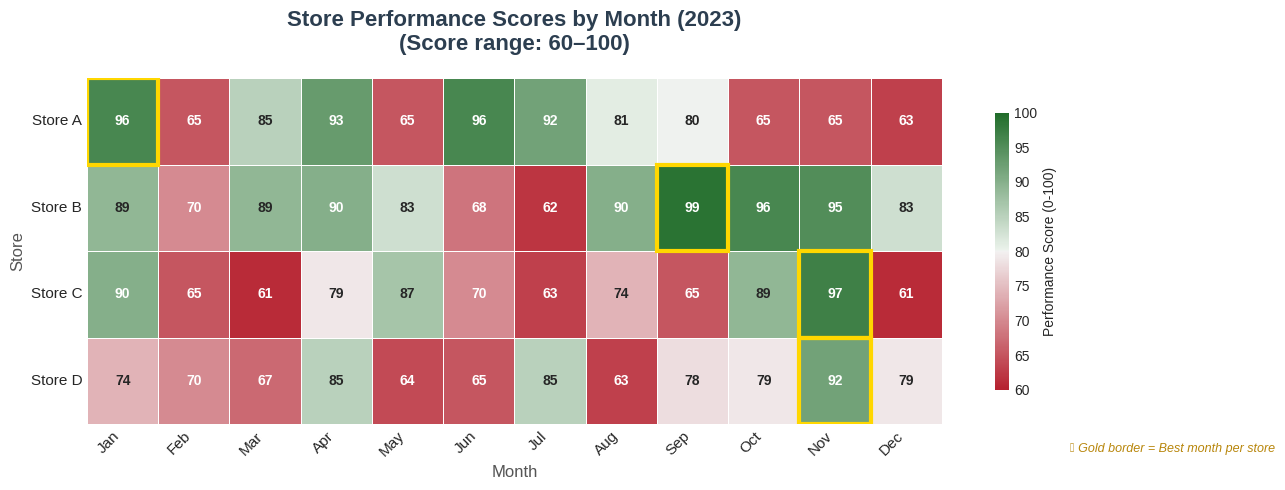

✅ Heatmap saved as 'chart6_heatmap.png'


In [ ]:
# ============================================================
# CHART 6 – HEATMAP
# Purpose : Show store performance scores across months
# Message : Which store performs best, and when?
# ============================================================

def plot_heatmap(data):
    """
    Color-coded heatmap for store vs. month performance.
    Best for: Comparing values across two categorical dimensions.
    """
    fig, ax = plt.subplots(figsize=(13, 5))

    # Create custom colormap (red → yellow → green)
    cmap = sns.diverging_palette(10, 130, s=85, l=40, n=256, as_cmap=True)

    sns.heatmap(
        data,
        ax          = ax,
        cmap        = cmap,
        annot       = True,          # show values in cells
        fmt         = 'd',           # integer format
        linewidths  = 0.5,
        linecolor   = 'white',
        cbar_kws    = {'label': 'Performance Score (0-100)',
                       'shrink': 0.8},
        vmin        = 60,
        vmax        = 100,
        annot_kws   = {'size': 10, 'weight': 'bold'}
    )

    # --- Styling ---
    ax.set_title('Store Performance Scores by Month (2023)\n'
                 '(Score range: 60–100)',
                 **TITLE_FONT, pad=20)
    ax.set_xlabel('Month', **LABEL_FONT)
    ax.set_ylabel('Store', **LABEL_FONT)

    ax.tick_params(axis='both', labelsize=11)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va='center')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Highlight best-performing month for each store
    for i, store in enumerate(data.index):
        best_month = data.loc[store].idxmax()
        best_col   = list(data.columns).index(best_month)
        ax.add_patch(plt.Rectangle(
            (best_col, i), 1, 1,
            fill=False, edgecolor='gold', lw=3
        ))

    # Add a legend note for the gold border
    ax.text(
        1.15, -0.08,
        '★ Gold border = Best month per store',
        transform  = ax.transAxes,
        fontsize   = 9,
        color      = '#B8860B',
        style      = 'italic'
    )

    plt.tight_layout()
    plt.savefig('chart6_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Heatmap saved as 'chart6_heatmap.png'")


plot_heatmap(store_performance)

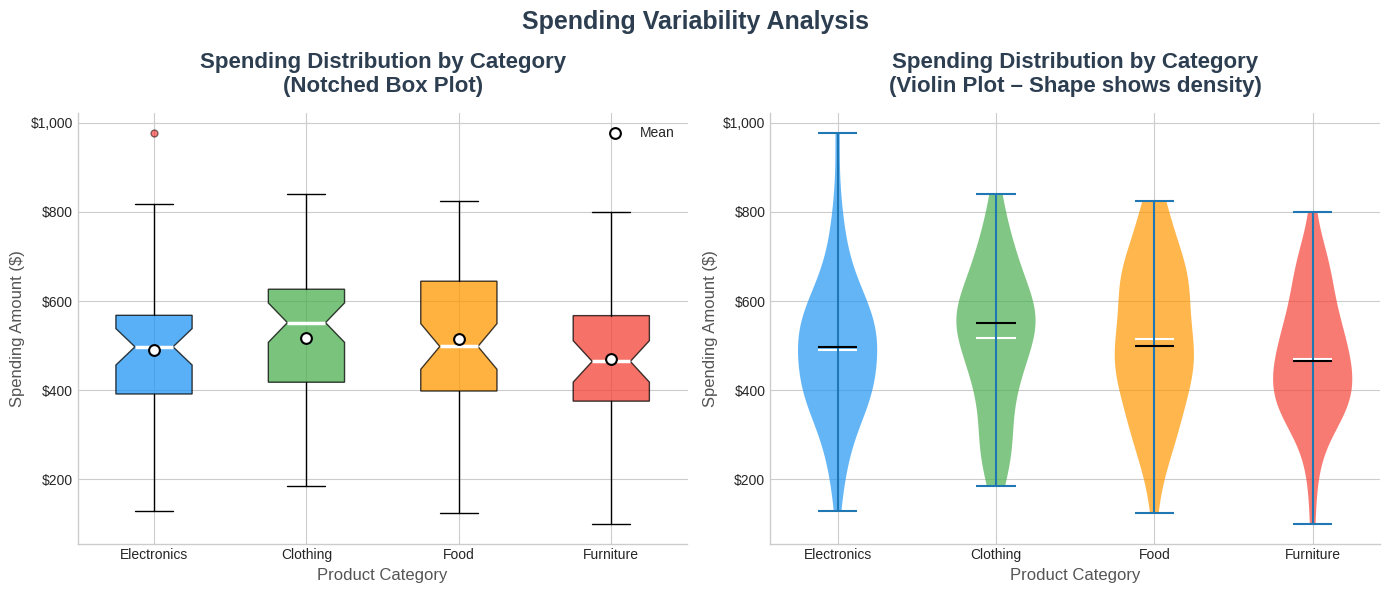

✅ Box Plot saved as 'chart7_box_plot.png'


In [ ]:
# ============================================================
# CHART 7 – BOX PLOT
# Purpose : Show spread and outliers in spending per category
# Message : Which category has the most variable spending?
# ============================================================

def plot_box_chart(data):
    """
    Box plot with swarm overlay for spending by category.
    Best for: Showing data spread, quartiles, and outliers.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ---- LEFT: Box Plot ----
    categories_order = ['Electronics', 'Clothing', 'Food', 'Furniture']

    bp = axes[0].boxplot(
        [data[data['Category'] == cat]['Spending']
         for cat in categories_order],
        labels    = categories_order,
        patch_artist = True,
        notch     = True,           # notched to show CI around median
        widths    = 0.5,
        flierprops= dict(marker='o', markerfacecolor='red',
                         markersize=5, alpha=0.5)
    )

    # Color each box
    for patch, color in zip(bp['boxes'], COLOR_PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # Style medians
    for median in bp['medians']:
        median.set_color('white')
        median.set_linewidth(2.5)

    # Add mean markers
    means = [data[data['Category'] == cat]['Spending'].mean()
             for cat in categories_order]
    axes[0].scatter(range(1, 5), means,
                    color='white', s=60, zorder=5,
                    edgecolors='black', linewidths=1.5,
                    label='Mean')

    axes[0].set_title('Spending Distribution by Category\n'
                      '(Notched Box Plot)',
                      **TITLE_FONT, pad=15)
    axes[0].set_xlabel('Product Category', **LABEL_FONT)
    axes[0].set_ylabel('Spending Amount ($)', **LABEL_FONT)
    axes[0].legend(fontsize=10)
    axes[0].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda val, _: f'${val:,.0f}')
    )
    axes[0].spines[['top', 'right']].set_visible(False)
    axes[0].tick_params(**TICK_FONT)

    # ---- RIGHT: Violin Plot (enriched view) ----
    parts = axes[1].violinplot(
        [data[data['Category'] == cat]['Spending']
         for cat in categories_order],
        positions  = range(1, 5),
        showmeans  = True,
        showmedians= True,
        showextrema= True
    )

    # Color each violin
    for i, (body, color) in enumerate(zip(parts['bodies'], COLOR_PALETTE)):
        body.set_facecolor(color)
        body.set_alpha(0.7)

    parts['cmeans'].set_color('white')
    parts['cmedians'].set_color('black')

    axes[1].set_xticks(range(1, 5))
    axes[1].set_xticklabels(categories_order)
    axes[1].set_title('Spending Distribution by Category\n'
                      '(Violin Plot – Shape shows density)',
                      **TITLE_FONT, pad=15)
    axes[1].set_xlabel('Product Category', **LABEL_FONT)
    axes[1].set_ylabel('Spending Amount ($)', **LABEL_FONT)
    axes[1].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda val, _: f'${val:,.0f}')
    )
    axes[1].spines[['top', 'right']].set_visible(False)
    axes[1].tick_params(**TICK_FONT)

    plt.suptitle('Spending Variability Analysis',
                 fontsize=18, fontweight='bold', color='#2C3E50')
    plt.tight_layout()
    plt.savefig('chart7_box_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Box Plot saved as 'chart7_box_plot.png'")


plot_box_chart(customer_data)

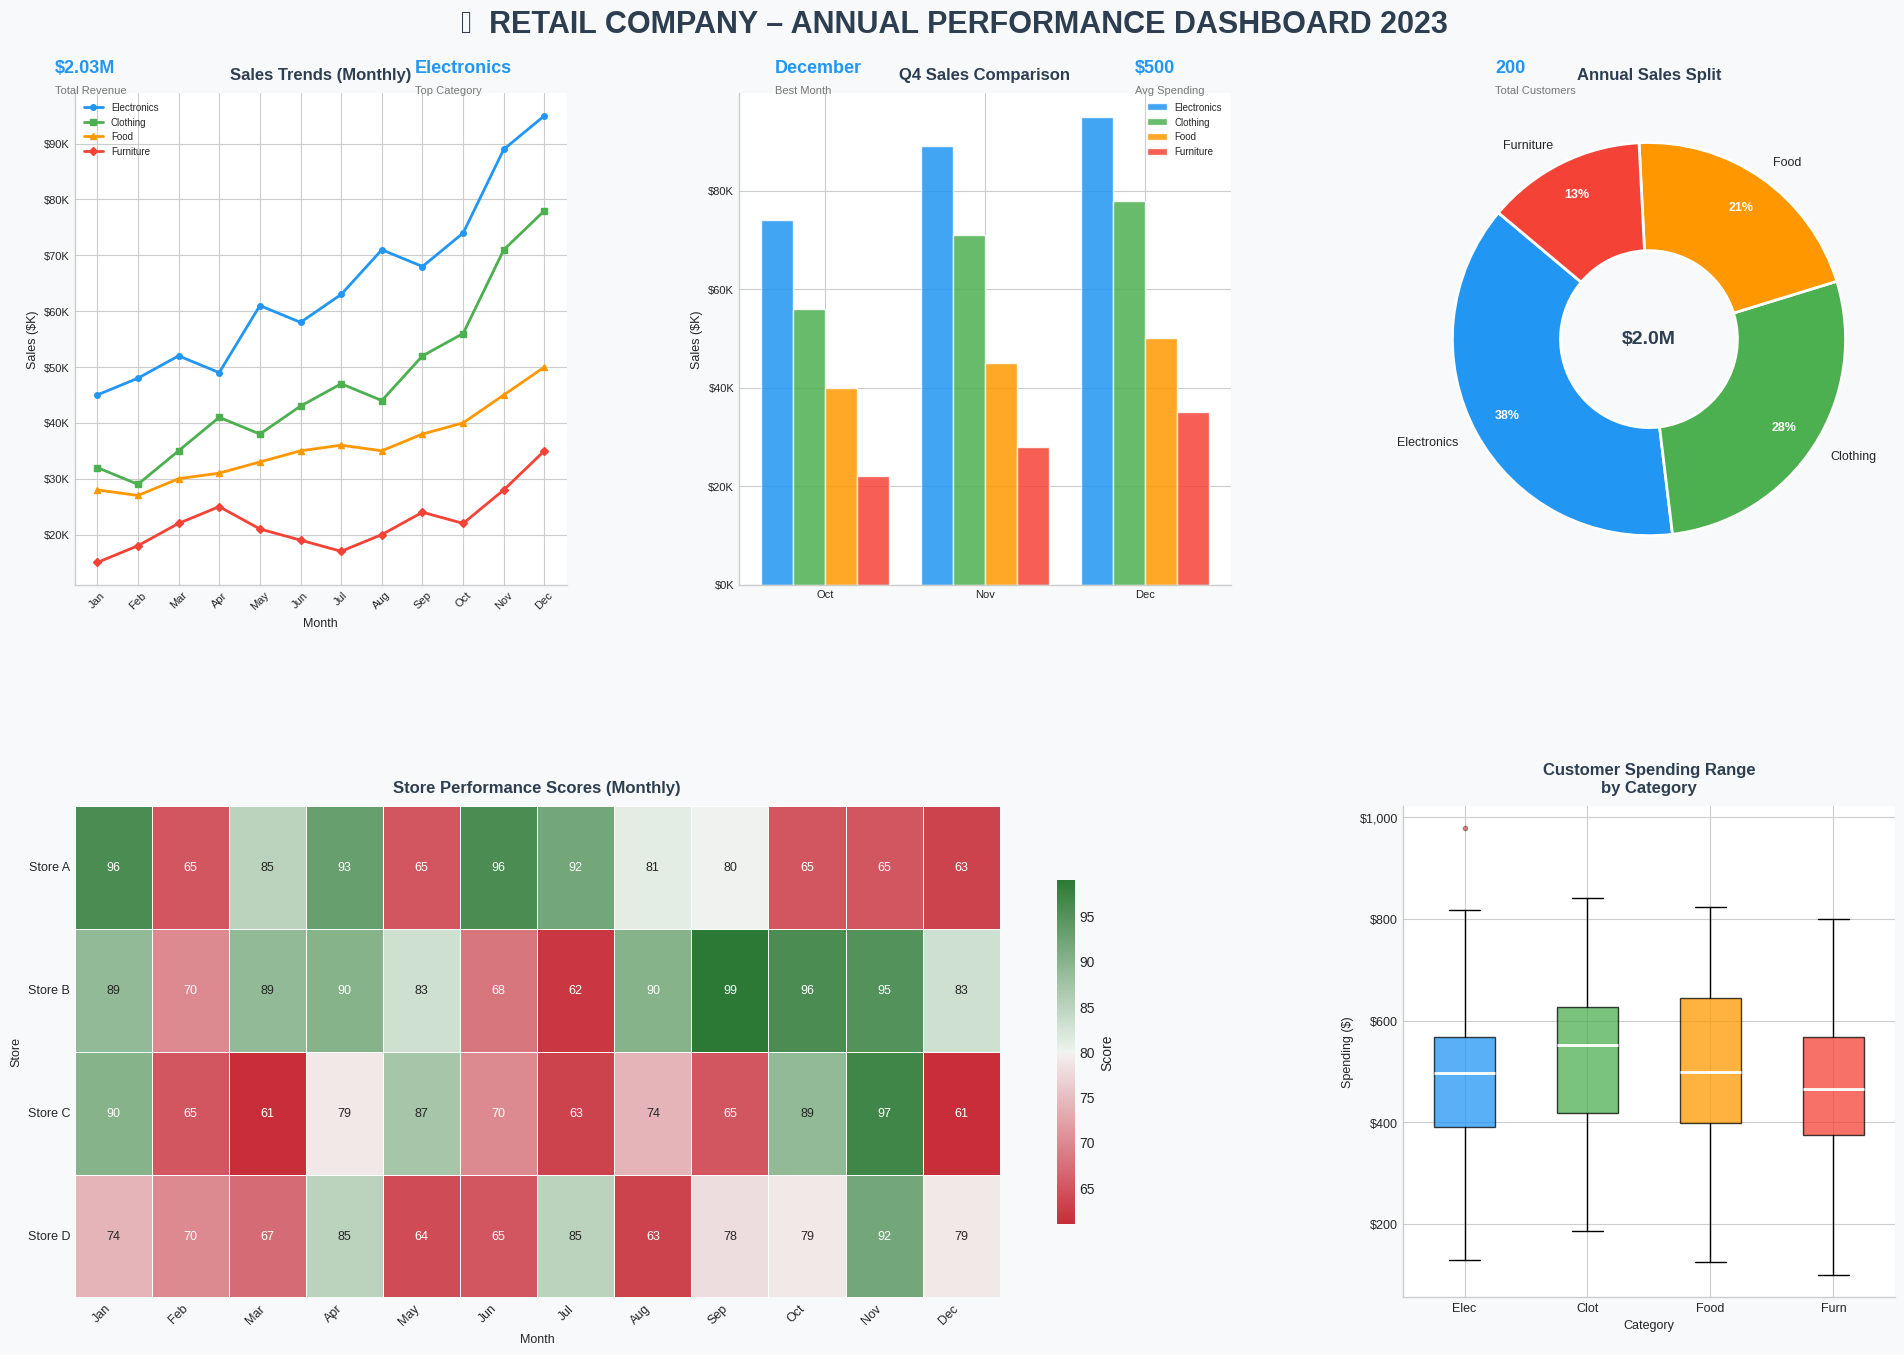

✅ Dashboard saved as 'chart8_dashboard.png'


In [ ]:
# ============================================================
# CHART 8 – EXECUTIVE DASHBOARD
# Purpose : Present all key insights in one view
# Message : Complete business overview at a glance
# ============================================================

def plot_dashboard(sales_data, customer_data, store_performance):
    """
    A comprehensive dashboard combining multiple chart types.
    Best for: Executive summaries and business reports.
    """
    fig = plt.figure(figsize=(20, 14))
    fig.patch.set_facecolor('#F8F9FA')

    # Add main title
    fig.suptitle(
        '📊  RETAIL COMPANY – ANNUAL PERFORMANCE DASHBOARD 2023',
        fontsize   = 22,
        fontweight = 'bold',
        color      = '#2C3E50',
        y          = 0.98
    )

    # --- Define Grid Layout ---
    # Row 1: 3 charts | Row 2: 2 charts
    gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35,
                          top=0.92, bottom=0.06,
                          left=0.06, right=0.97)

    ax1 = fig.add_subplot(gs[0, 0])     # Line chart
    ax2 = fig.add_subplot(gs[0, 1])     # Bar chart (Q4)
    ax3 = fig.add_subplot(gs[0, 2])     # Pie chart
    ax4 = fig.add_subplot(gs[1, 0:2])   # Heatmap
    ax5 = fig.add_subplot(gs[1, 2])     # Box plot summary

    categories = ['Electronics', 'Clothing', 'Food', 'Furniture']

    # =====================================================
    # PANEL 1: Sales Trends (Line)
    # =====================================================
    for category, color, marker in zip(
            categories, COLOR_PALETTE, ['o','s','^','D']):
        ax1.plot(
            sales_data['Month'],
            sales_data[category] / 1000,
            color=color, marker=marker,
            markersize=4, linewidth=2, label=category
        )
    ax1.set_title('Sales Trends (Monthly)', fontsize=12,
                  fontweight='bold', color='#2C3E50', pad=10)
    ax1.set_xlabel('Month', fontsize=9)
    ax1.set_ylabel('Sales ($K)', fontsize=9)
    ax1.legend(fontsize=7, loc='upper left')
    ax1.tick_params(labelsize=8, axis='x', rotation=45)
    ax1.tick_params(labelsize=8, axis='y')
    ax1.spines[['top','right']].set_visible(False)
    ax1.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v,_: f'${v:.0f}K'))

    # =====================================================
    # PANEL 2: Q4 Sales Bar Chart
    # =====================================================
    q4_data  = sales_data[sales_data['Month'].isin(['Oct','Nov','Dec'])]
    x        = np.arange(3)
    width    = 0.2

    for i, (cat, color) in enumerate(zip(categories, COLOR_PALETTE)):
        ax2.bar(x + i * width,
                q4_data[cat].values / 1000,
                width=width, color=color,
                label=cat, alpha=0.85, edgecolor='white')

    ax2.set_title('Q4 Sales Comparison', fontsize=12,
                  fontweight='bold', color='#2C3E50', pad=10)
    ax2.set_xticks(x + width * 1.5)
    ax2.set_xticklabels(['Oct', 'Nov', 'Dec'], fontsize=9)
    ax2.set_ylabel('Sales ($K)', fontsize=9)
    ax2.tick_params(labelsize=8)
    ax2.legend(fontsize=7)
    ax2.spines[['top','right']].set_visible(False)
    ax2.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v,_: f'${v:.0f}K'))

    # =====================================================
    # PANEL 3: Sales Distribution (Donut)
    # =====================================================
    totals  = [sales_data[cat].sum() for cat in categories]
    wedges, texts, autotexts = ax3.pie(
        totals,
        labels     = categories,
        colors     = COLOR_PALETTE[:4],
        autopct    = '%1.0f%%',
        startangle = 140,
        pctdistance= 0.82,
        wedgeprops = dict(width=0.55, edgecolor='white', linewidth=2)
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_fontweight('bold')
        at.set_color('white')
    for t in texts:
        t.set_fontsize(9)

    total_all = sum(totals)
    ax3.text(0, 0, f'${total_all/1e6:.1f}M',
             ha='center', va='center',
             fontsize=14, fontweight='bold', color='#2C3E50')
    ax3.set_title('Annual Sales Split', fontsize=12,
                  fontweight='bold', color='#2C3E50', pad=10)

    # =====================================================
    # PANEL 4: Heatmap
    # =====================================================
    cmap = sns.diverging_palette(10, 130, s=80, l=45, n=256, as_cmap=True)
    sns.heatmap(
        store_performance,
        ax         = ax4,
        cmap       = cmap,
        annot      = True,
        fmt        = 'd',
        linewidths = 0.4,
        linecolor  = 'white',
        annot_kws  = {'size': 9},
        cbar_kws   = {'shrink': 0.7, 'label': 'Score'}
    )
    ax4.set_title('Store Performance Scores (Monthly)',
                  fontsize=12, fontweight='bold', color='#2C3E50', pad=10)
    ax4.set_xlabel('Month', fontsize=9)
    ax4.set_ylabel('Store', fontsize=9)
    ax4.tick_params(labelsize=9)
    ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0)
    ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')

    # =====================================================
    # PANEL 5: Box Plot Summary
    # =====================================================
    bp = ax5.boxplot(
        [customer_data[customer_data['Category'] == cat]['Spending']
         for cat in categories],
        labels       = [c[:4] for c in categories],  # shorten labels
        patch_artist = True,
        notch        = False,
        widths       = 0.5,
        flierprops   = dict(marker='o', markersize=3,
                            markerfacecolor='red', alpha=0.4)
    )
    for patch, color in zip(bp['boxes'], COLOR_PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    for median in bp['medians']:
        median.set_color('white')
        median.set_linewidth(2)

    ax5.set_title('Customer Spending Range\nby Category',
                  fontsize=12, fontweight='bold', color='#2C3E50', pad=10)
    ax5.set_xlabel('Category', fontsize=9)
    ax5.set_ylabel('Spending ($)', fontsize=9)
    ax5.tick_params(labelsize=9)
    ax5.spines[['top','right']].set_visible(False)
    ax5.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v,_: f'${v:,.0f}'))

    # =====================================================
    # Add KPI Summary Strip (top of figure)
    # =====================================================
    kpis = {
        'Total Revenue'    : f"${sales_data[categories].sum().sum()/1e6:.2f}M",
        'Top Category'     : 'Electronics',
        'Best Month'       : 'December',
        'Avg Spending'     : f"${customer_data['Spending'].mean():.0f}",
        'Total Customers'  : f"{len(customer_data):,}"
    }

    kpi_x = 0.05
    for label, value in kpis.items():
        fig.text(kpi_x, 0.935, value,
                 fontsize=13, fontweight='bold', color='#2196F3',
                 ha='left', transform=fig.transFigure)
        fig.text(kpi_x, 0.920, label,
                 fontsize=8, color='#777777',
                 ha='left', transform=fig.transFigure)
        kpi_x += 0.18

    plt.savefig('chart8_dashboard.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print("✅ Dashboard saved as 'chart8_dashboard.png'")


plot_dashboard(sales_data, customer_data, store_performance)